In [1]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   -- ------------------------------------- 7.3/101.7 MB 39.5 MB/s eta 0:00:03
   ------- -------------------------------- 20.2/101.7 MB 52.5 MB/s eta 0:00:02
   ------------ --------------------------- 32.5/101.7 MB 55.7 MB/s eta 0:00:02
   ---------------- ----------------------- 41.9/101.7 MB 52.4 MB/s eta 0:00:02
   ---------------------- ----------------- 56.9/101.7 MB 56.0 MB/s eta 0:00:01
   ---------------------------- ----------- 73.7/101.7 MB 60.0 MB/s eta 0:00:01
   ----------------------------------- ---- 91.2/101.7 MB 63.0 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 63.8 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 63.8 MB/s eta 0:00:01
   --------------------------------------- 101.7/101.7 MB 52.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np

# 1. โหลดข้อมูล Features (590 คอลัมน์)
url_features = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
df_features = pd.read_csv(url_features, sep=r"\s+", header=None)

# 2. โหลดข้อมูล Labels (แก้ไขโดยเพิ่มชื่อคอลัมน์เข้าไป)
url_labels = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"
df_labels = pd.read_csv(url_labels, sep=r"\s+", header=None, names=['Result', 'Date'])

# 3. รวมข้อมูลเข้าด้วยกัน
# ปรับค่า Target ให้เป็น 0 (ปกติ) และ 1 (ของเสีย) 
df_labels['Result'] = df_labels['Result'].replace(-1, 0)
df = pd.concat([df_features, df_labels], axis=1)

print(f"โหลดข้อมูลสำเร็จ ขนาด: {df.shape}")
print(f"จำนวนของเสีย (Defects) ที่พบ: {df['Result'].sum()} รายการ จากทั้งหมด {len(df)} รายการ")

โหลดข้อมูลสำเร็จ ขนาด: (1567, 592)
จำนวนของเสีย (Defects) ที่พบ: 104 รายการ จากทั้งหมด 1567 รายการ


In [14]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,582,583,584,585,586,587,588,589,Result,Date
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,0,19/07/2008 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,0,19/07/2008 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,19/07/2008 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,0,19/07/2008 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,0,19/07/2008 15:22:00


In [15]:
df = df.drop(columns=['Date'])  # ลบคอลัมน์ Date ออก

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def wilson_filter(df, attribute_col, target_col, confidence=0.95, threshold=0.1):
    """
    ฟังก์ชันสำหรับกรองปัจจัยที่มีอัตราของเสียสูงแต่ปริมาณน้อยออก
    """
    stats = df.groupby(attribute_col)[target_col].agg(['sum', 'count']).reset_index()
    stats.columns = [attribute_col, 'defects', 'total']
    
    def calculate_lower_bound(row):
        n = row['total']
        if n == 0: return 0
        p_hat = row['defects'] / n
        z = norm.ppf(1 - (1 - confidence) / 2)
        
        # สูตร Wilson Score Interval
        denominator = 1 + z**2/n
        centre = (p_hat + z**2/(2*n)) / denominator
        margin = z/denominator * np.sqrt(p_hat*(1-p_hat)/n + z**2/(4*n**2))
        return centre - margin

    stats['lower_bound'] = stats.apply(calculate_lower_bound, axis=1)
    
    # เลือกเฉพาะปัจจัยที่มีความนัยสำคัญ (Lower Bound เกินเกณฑ์)
    significant_factors = stats[stats['lower_bound'] > threshold]
    return significant_factors

In [11]:
import xgboost as xgb
import shap
from sklearn.feature_selection import VarianceThreshold

def rca_pipeline(X, y):
    # กรองตัวแปรที่ไม่มีความแปรปรวน (Zero Variance)
    selector = VarianceThreshold(threshold=0)
    X_reduced = pd.DataFrame(selector.fit_transform(X), columns=X.columns[selector.get_support()])
    
    # ฝึกโมเดล XGBoost
    model = xgb.XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=10)
    model.fit(X_reduced, y)
    
    # ใช้ SHAP เพื่อวิเคราะห์สาเหตุรากเหง้า
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_reduced)
    
    # แสดงผลความสำคัญของสาเหตุ
    shap.summary_plot(shap_values, X_reduced, plot_type="bar")
    
    return model, shap_values

In [12]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils

def build_causal_graph(data, labels):
    # ค้นหาโครงสร้างเชิงเหตุผลด้วยอัลกอริทึม PC
    cg = pc(data.to_numpy())
    
    # การแสดงผลโหนดที่เชื่อมโยงกัน
    pyd = GraphUtils.to_pydot(cg.G, labels=labels)
    pyd.write_png('causal_graph.png')
    return cg

In [21]:
# จัดการค่าว่างด้วยการเติมค่าเฉลี่ย (Mean Imputation)
df_clean = df.fillna(df.mean())

# แยก Feature (X) และ Target (y)
X = df_clean.iloc[:, :590] # คอลัมน์ 0 ถึง 589
y = df_clean["Result"]      # คอลัมน์ผลลัพธ์ Pass/Fail

In [20]:
df_clean

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Result
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.500500,0.016200,...,97.934373,0.5005,0.0118,0.0035,2.3630,0.021458,0.016475,0.005283,99.670066,0
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.496600,-0.000500,...,208.204500,0.5019,0.0223,0.0055,4.4447,0.009600,0.020100,0.006000,208.204500,0
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.443600,0.004100,...,82.860200,0.4958,0.0157,0.0039,3.1745,0.058400,0.048400,0.014800,82.860200,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.488200,-0.012400,...,73.843200,0.4990,0.0103,0.0025,2.0544,0.020200,0.014900,0.004400,73.843200,0
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.503100,-0.003100,...,97.934373,0.4800,0.4766,0.1045,99.3032,0.020200,0.014900,0.004400,73.843200,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.342400,-0.004500,...,203.172000,0.4988,0.0143,0.0039,2.8669,0.006800,0.013800,0.004700,203.172000,0
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.433300,-0.006100,...,97.934373,0.4975,0.0131,0.0036,2.6238,0.006800,0.013800,0.004700,203.172000,0
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,1.462862,-0.000841,...,43.523100,0.4987,0.0153,0.0041,3.0590,0.019700,0.008600,0.002500,43.523100,0
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.462200,-0.007200,...,93.494100,0.5004,0.0178,0.0038,3.5662,0.026200,0.024500,0.007500,93.494100,0


In [22]:
# สมมติว่าต้องการตรวจสอบเซ็นเซอร์คอลัมน์ที่ '0' ว่าเป็นสาเหตุที่มีนัยสำคัญหรือไม่
significant_results = wilson_filter(df_clean, attribute_col=0, target_col='Result', threshold=0.05)

if not significant_results.empty:
    print("เซ็นเซอร์นี้มีนัยสำคัญทางสถิติ")
else:
    print("เซ็นเซอร์นี้มีจำนวนเคสน้อยเกินไป หรืออัตราของเสียน้อยเกินไป ไม่นำมาพิจารณา")

เซ็นเซอร์นี้มีนัยสำคัญทางสถิติ


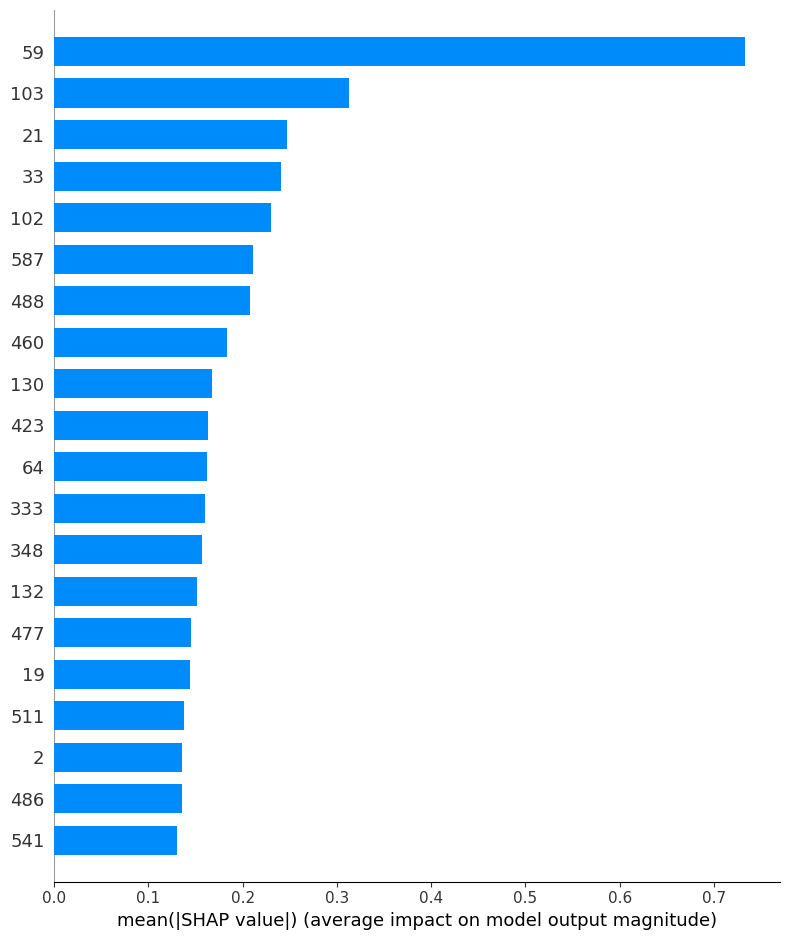

In [23]:
# เรียกใช้ Pipeline เพื่อฝึกโมเดลและหาค่าความสำคัญ
model, shap_values = rca_pipeline(X, y)

# หมายเหตุ: ฟังก์ชันจะแสดงกราฟ Summary Plot ของ SHAP ให้โดยอัตโนมัติ 
# เพื่อให้คุณเห็นว่าเซ็นเซอร์ตัวไหน (0-589) ที่ส่งผลต่อของเสียมากที่สุด

In [26]:
# 1. คำนวณค่าความสำคัญเฉลี่ยจาก SHAP
# shap_values[1] คือค่าอิทธิพลต่อการเกิด "ของเสีย" (Class 1)
mean_shap_importance = np.abs(shap_values[1]).mean(axis=0)

# 2. สร้าง DataFrame เพื่อเรียงลำดับชื่อเซ็นเซอร์ตามความสำคัญ
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': mean_shap_importance
}).sort_values(by='importance', ascending=False)

# 3. เลือก Top 5 หรือ Top 10 ที่มีผลมากที่สุดมาสร้างกราฟโหนด
n_top = 10
top_features_names = feature_importance_df.head(n_top)['feature'].tolist()
labels = [str(f) for f in top_features_names]

# 4. ส่งข้อมูลเฉพาะคอลัมน์ที่ SHAP บอกว่าสำคัญไปสร้างโหนดเชื่อมโยงสาเหตุ
causal_graph = build_causal_graph(X[top_features_names], labels)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  0%|          | 0/10 [00:00<?, ?it/s]